# 04 - Ablation Studies

This notebook evaluates the robustness and reproducibility of the DenseNet-Attention model.
All runs are optionally tracked with Weights & Biases (if configured in .env).

1. Data augmentation level (none / basic / standard / heavy)
2. Training set size (25% / 50% / 75% / 100%)
3. Model components (attention module, focal loss)
4. Multiple runs with different random seeds

In [1]:
import sys
sys.path.insert(0, "..")

import os
import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data import get_dataloaders
from src.models import get_model, get_optimizer, FocalLoss
from src.train import train_one_epoch, validate
from src.evaluate import evaluate_model, compute_metrics, plot_confusion_matrix
from src.utils import set_seed, get_device, load_config, save_results, count_parameters
from src.wandb_utils import (
    setup_wandb, wandb_init, wandb_log, wandb_summary,
    wandb_log_image, wandb_log_table, wandb_finish,
)

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

load_dotenv("../.env")
USE_WANDB = setup_wandb()

config = load_config("../configs/default.yaml")
device = get_device()
DATA_ROOT = "../data/chest_xray"
SEED = config["reproducibility"]["seed"]
SEEDS = config["reproducibility"]["seeds_for_multiple_runs"]

print(f"Device: {device}")
print(f"Wandb tracking: {'enabled' if USE_WANDB else 'disabled'}")
print(f"Seeds for multi-run experiments: {SEEDS}")

wandb: Currently logged in as: nevin-helfenstein (medimg-pneumonia-detection) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[wandb] Logged in. Project: medimg-pneumonia-detection
Device: cuda
Wandb tracking: enabled
Seeds for multi-run experiments: [42, 123, 456, 789, 1024]


In [2]:
def run_ablation_with_wandb(
    model_kwargs, data_kwargs, run_config, experiment_name,
    seed=42, wandb_tags=None, wandb_group=None,
):
    """Train a single ablation run with optional wandb tracking."""
    set_seed(seed)

    dataloaders = get_dataloaders(
        DATA_ROOT, num_workers=0, seed=seed, **data_kwargs,
    )

    model = get_model("densenet_attention", **model_kwargs)
    use_focal = run_config.get("model", {}).get("use_focal_loss", False)

    wandb_config = {
        "model": "densenet_attention",
        "seed": seed,
        "use_attention": model_kwargs.get("use_attention", True),
        "use_focal_loss": use_focal,
        "augmentation": data_kwargs.get("augmentation", "standard"),
        "train_fraction": data_kwargs.get("train_fraction", 1.0),
        "epochs": run_config["training"]["num_epochs"],
        "batch_size": run_config["training"]["batch_size"],
        "learning_rate": run_config["training"]["learning_rate"],
        "train_size": dataloaders["info"]["train_size"],
        **count_parameters(model),
    }

    run = wandb_init(
        name=experiment_name,
        config=wandb_config,
        tags=wandb_tags or [],
        group=wandb_group,
        reinit=True,
    ) if USE_WANDB else None

    if use_focal:
        criterion = FocalLoss(
            alpha=run_config["model"].get("focal_loss_alpha", 0.6),
            gamma=run_config["model"].get("focal_loss_gamma", 2.0),
        )
    else:
        train_info = dataloaders["info"]["train_class_dist"]
        pos_weight = torch.tensor([train_info.get(0, 1) / train_info.get(1, 1)]).to(device)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    lr = run_config["training"]["learning_rate"]
    wd = run_config["training"]["weight_decay"]
    optimizer = get_optimizer(model, "densenet_attention", lr=lr, weight_decay=wd)
    scheduler = CosineAnnealingLR(optimizer, T_max=run_config["training"]["num_epochs"])

    model = model.to(device)
    best_auroc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    patience = run_config["training"]["early_stopping_patience"]
    epochs_no_improve = 0

    for epoch in range(1, run_config["training"]["num_epochs"] + 1):
        train_loss = train_one_epoch(model, dataloaders["train"], criterion, optimizer, device)
        val_loss, val_metrics = validate(model, dataloaders["val"], criterion, device)
        scheduler.step()

        wandb_log({
            "epoch": epoch,
            "train/loss": train_loss,
            "val/loss": val_loss,
            "val/auroc": val_metrics["auroc"],
            "val/f1_macro": val_metrics["f1_macro"],
            "val/sensitivity": val_metrics["sensitivity"],
            "val/specificity": val_metrics["specificity"],
        }, run)

        improved = val_metrics["auroc"] > best_auroc
        if improved:
            best_auroc = val_metrics["auroc"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        status = "*" if improved else ""
        print(
            f"Epoch {epoch:3d}/{run_config['training']['num_epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val AUROC: {val_metrics['auroc']:.4f} | "
            f"F1: {val_metrics['f1_macro']:.4f} {status}"
        )

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    test_results = evaluate_model(model, dataloaders["test"], device)
    test_m = test_results["metrics"]

    wandb_log({
        "test/auroc": test_m["auroc"],
        "test/f1_macro": test_m["f1_macro"],
        "test/sensitivity": test_m["sensitivity"],
        "test/specificity": test_m["specificity"],
        "test/npv": test_m["npv"],
    }, run)

    wandb_summary({
        "test_auroc": test_m["auroc"],
        "test_f1": test_m["f1_macro"],
        "test_sensitivity": test_m["sensitivity"],
        "test_specificity": test_m["specificity"],
        "best_val_auroc": best_auroc,
    }, run)

    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
    plot_confusion_matrix(
        test_results["y_true"], test_results["y_proba"],
        title=experiment_name, ax=ax_cm,
    )
    plt.tight_layout()
    wandb_log_image("test/confusion_matrix", fig_cm, run)
    plt.close(fig_cm)

    wandb_finish(run)

    print(f"  AUROC: {test_m['auroc']:.4f}, F1: {test_m['f1_macro']:.4f}")
    return test_m

## Ablation 1: Data Augmentation Level

| Level | Transforms applied during training |
|-------|------------------------------------|
| **none** | Resize(224, 224), ImageNet normalize. No augmentation at all. |
| **basic** | Resize(224, 224), HorizontalFlip (p=0.5), Rotate (limit=10 deg, p=0.3), ImageNet normalize. |
| **standard** | RandomResizedCrop(224, scale=0.85-1.0), HorizontalFlip (p=0.5), Rotate (limit=15 deg, p=0.4), RandomBrightnessContrast (brightness=0.2, contrast=0.2, p=0.4), GaussianBlur (kernel=3-5, p=0.2), ImageNet normalize. |
| **heavy** | RandomResizedCrop(224, scale=0.8-1.0), HorizontalFlip (p=0.5), Rotate (limit=20 deg, p=0.5), RandomBrightnessContrast (brightness=0.3, contrast=0.3, p=0.5), ElasticTransform (alpha=40, sigma=2.0, p=0.2), GridDistortion (steps=5, limit=0.1, p=0.2), CoarseDropout (p=0.2), GaussianBlur (kernel=3-7, p=0.3), ImageNet normalize. |

In [3]:
aug_levels = ["none", "basic", "standard", "heavy"]
aug_results = {}

for level in aug_levels:
    print(f"\n{'='*60}")
    print(f"Training with augmentation: {level}")
    print(f"{'='*60}")

    data_kwargs = {
        "augmentation": level,
        "image_size": config["data"]["image_size"],
        "batch_size": config["training"]["batch_size"],
        "val_split": config["data"]["val_split"],
    }
    model_kwargs = {
        "pretrained": True,
        "dropout": config["model"]["dropout"],
        "use_attention": True,
    }

    metrics = run_ablation_with_wandb(
        model_kwargs, data_kwargs, config,
        experiment_name=f"ablation_aug_{level}",
        seed=SEED,
        wandb_tags=["ablation", "augmentation"],
        wandb_group="augmentation_ablation",
    )
    aug_results[level] = metrics


Training with augmentation: none


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/15 | Train Loss: 0.0147 | Val Loss: 0.0086 | Val AUROC: 0.9986 | F1: 0.9586 *
Epoch   2/15 | Train Loss: 0.0052 | Val Loss: 0.0068 | Val AUROC: 0.9985 | F1: 0.9820 
Epoch   3/15 | Train Loss: 0.0028 | Val Loss: 0.0048 | Val AUROC: 0.9993 | F1: 0.9850 *
Epoch   4/15 | Train Loss: 0.0014 | Val Loss: 0.0037 | Val AUROC: 0.9997 | F1: 0.9882 *
Epoch   5/15 | Train Loss: 0.0012 | Val Loss: 0.0063 | Val AUROC: 0.9996 | F1: 0.9745 
Epoch   6/15 | Train Loss: 0.0004 | Val Loss: 0.0035 | Val AUROC: 0.9995 | F1: 0.9883 
Epoch   7/15 | Train Loss: 0.0011 | Val Loss: 0.0021 | Val AUROC: 0.9998 | F1: 0.9933 *
Epoch   8/15 | Train Loss: 0.0007 | Val Loss: 0.0036 | Val AUROC: 0.9996 | F1: 0.9883 
Epoch   9/15 | Train Loss: 0.0002 | Val Loss: 0.0042 | Val AUROC: 0.9996 | F1: 0.9950 
Epoch  10/15 | Train Loss: 0.0001 | Val Loss: 0.0033 | Val AUROC: 0.9998 | F1: 0.9917 
Epoch  11/15 | Train Loss: 0.0001 | Val Loss: 0.0025 | Val AUROC: 0.9998 | F1: 0.9933 *
Epoch  12/15 | Train Loss: 0.0001 | Va

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▃▂▂▂▁▂▁▁▁▁▁▁▁▁
val/auroc,▁▁▅▇▇▆█▇▇██▇███
val/f1_macro,▁▅▆▇▄▇█▇█▇█▇███
val/loss,█▆▄▃▅▃▁▃▃▂▁▂▂▂▂
val/sensitivity,▇▁▆██▇▇▇▇▇▇▇▇▇▇


  AUROC: 0.9640, F1: 0.7463

Training with augmentation: basic


...

  AUROC: 0.9860, F1: 0.8260

Training with augmentation: heavy


c:\git\HSLU\HSLU.MEDIMG.Project\notebooks\..\src\data.py:122: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=30, max_width=30, p=0.2),


Epoch   1/15 | Train Loss: 0.0280 | Val Loss: 0.0090 | Val AUROC: 0.9970 | F1: 0.9678 *
Epoch   2/15 | Train Loss: 0.0167 | Val Loss: 0.0100 | Val AUROC: 0.9970 | F1: 0.9673 
Epoch   3/15 | Train Loss: 0.0143 | Val Loss: 0.0059 | Val AUROC: 0.9981 | F1: 0.9815 *
Epoch   4/15 | Train Loss: 0.0127 | Val Loss: 0.0074 | Val AUROC: 0.9979 | F1: 0.9751 
Epoch   5/15 | Train Loss: 0.0104 | Val Loss: 0.0073 | Val AUROC: 0.9981 | F1: 0.9802 *
Epoch   6/15 | Train Loss: 0.0093 | Val Loss: 0.0073 | Val AUROC: 0.9986 | F1: 0.9738 *
Epoch   7/15 | Train Loss: 0.0096 | Val Loss: 0.0054 | Val AUROC: 0.9986 | F1: 0.9850 *
Epoch   8/15 | Train Loss: 0.0065 | Val Loss: 0.0062 | Val AUROC: 0.9983 | F1: 0.9884 
Epoch   9/15 | Train Loss: 0.0070 | Val Loss: 0.0081 | Val AUROC: 0.9987 | F1: 0.9819 *
Epoch  10/15 | Train Loss: 0.0058 | Val Loss: 0.0067 | Val AUROC: 0.9989 | F1: 0.9803 *
Epoch  11/15 | Train Loss: 0.0051 | Val Loss: 0.0089 | Val AUROC: 0.9989 | F1: 0.9803 *
Epoch  12/15 | Train Loss: 0.0051 |

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▅▄▄▃▃▃▂▂▂▂▂▁▁▁
val/auroc,▁▁▅▄▅▇▇▆▇███▇▇▇
val/f1_macro,▁▁▆▄▅▃▇█▆▅▅▆▃▆▅
val/loss,▆█▂▄▄▄▁▂▅▃▆▃█▅▇
val/sensitivity,▇▁█▅▅▃▇▇▅▄▄▄▂▅▄


  AUROC: 0.9917, F1: 0.9012


Augmentation    AUROC  F1 (macro)  Sensitivity  Specificity
        none 0.964048    0.746253     1.000000     0.461538
       basic 0.964256    0.687546     0.997436     0.367521
    standard 0.986018    0.825952     0.994872     0.615385
       heavy 0.991694    0.901195     0.992308     0.777778


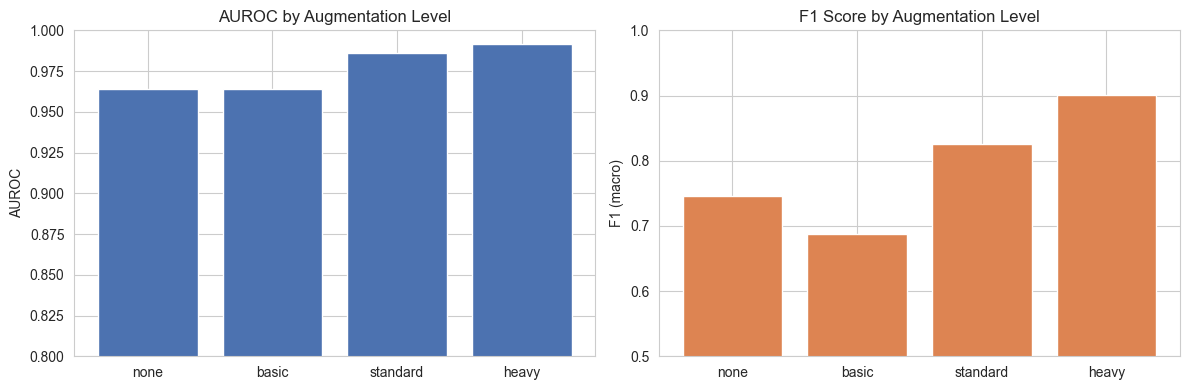

In [4]:
aug_df = pd.DataFrame([
    {"Augmentation": level, "AUROC": r["auroc"], "F1 (macro)": r["f1_macro"],
     "Sensitivity": r["sensitivity"], "Specificity": r["specificity"]}
    for level, r in aug_results.items()
])
print(aug_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(aug_df["Augmentation"], aug_df["AUROC"], color="#4C72B0")
axes[0].set_ylabel("AUROC")
axes[0].set_title("AUROC by Augmentation Level")
axes[0].set_ylim(0.8, 1.0)
axes[1].bar(aug_df["Augmentation"], aug_df["F1 (macro)"], color="#DD8452")
axes[1].set_ylabel("F1 (macro)")
axes[1].set_title("F1 Score by Augmentation Level")
axes[1].set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("../results/ablation_augmentation.png", bbox_inches="tight")
plt.show()

## Ablation 2: Training Set Size

Stratified subsampling to maintain the original class ratio.

In [5]:
fractions = [0.25, 0.50, 0.75, 1.0]
size_results = {}

for frac in fractions:
    print(f"\n{'='*60}")
    print(f"Training with {frac*100:.0f}% of training data")
    print(f"{'='*60}")

    data_kwargs = {
        "augmentation": "standard",
        "image_size": config["data"]["image_size"],
        "batch_size": config["training"]["batch_size"],
        "val_split": config["data"]["val_split"],
        "train_fraction": frac,
    }
    model_kwargs = {
        "pretrained": True,
        "dropout": config["model"]["dropout"],
        "use_attention": True,
    }

    metrics = run_ablation_with_wandb(
        model_kwargs, data_kwargs, config,
        experiment_name=f"ablation_size_{int(frac*100)}pct",
        seed=SEED,
        wandb_tags=["ablation", "data_size"],
        wandb_group="data_size_ablation",
    )
    size_results[frac] = metrics


Training with 25% of training data


Epoch   1/15 | Train Loss: 0.0357 | Val Loss: 0.0126 | Val AUROC: 0.9935 | F1: 0.9585 *
Epoch   2/15 | Train Loss: 0.0185 | Val Loss: 0.0128 | Val AUROC: 0.9954 | F1: 0.9579 *
Epoch   3/15 | Train Loss: 0.0116 | Val Loss: 0.0158 | Val AUROC: 0.9950 | F1: 0.9641 
Epoch   4/15 | Train Loss: 0.0116 | Val Loss: 0.0134 | Val AUROC: 0.9968 | F1: 0.9581 *
Epoch   5/15 | Train Loss: 0.0093 | Val Loss: 0.0102 | Val AUROC: 0.9964 | F1: 0.9671 
Epoch   6/15 | Train Loss: 0.0070 | Val Loss: 0.0091 | Val AUROC: 0.9970 | F1: 0.9733 *
Epoch   7/15 | Train Loss: 0.0033 | Val Loss: 0.0105 | Val AUROC: 0.9974 | F1: 0.9751 *
Epoch   8/15 | Train Loss: 0.0053 | Val Loss: 0.0188 | Val AUROC: 0.9952 | F1: 0.9656 
Epoch   9/15 | Train Loss: 0.0039 | Val Loss: 0.0131 | Val AUROC: 0.9959 | F1: 0.9673 
Epoch  10/15 | Train Loss: 0.0038 | Val Loss: 0.0100 | Val AUROC: 0.9967 | F1: 0.9736 
Epoch  11/15 | Train Loss: 0.0022 | Val Loss: 0.0102 | Val AUROC: 0.9970 | F1: 0.9703 
Epoch  12/15 | Train Loss: 0.0048 | Va

epoch,▁▂▂▃▄▄▅▅▆▇▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▄▃▃▂▂▁▂▁▁▁▂
val/auroc,▁▄▄▇▆▇█▄▅▇▇█
val/f1_macro,▁▁▄▁▅▇█▄▅▇▆▄
val/loss,▄▄▆▄▂▁▂█▄▂▂▄
val/sensitivity,▅▂▄▁▅██▅▅▇▆▄


  AUROC: 0.9876, F1: 0.8404

Training with 50% of training data


Epoch   1/15 | Train Loss: 0.0253 | Val Loss: 0.0107 | Val AUROC: 0.9956 | F1: 0.9683 *
Epoch   2/15 | Train Loss: 0.0146 | Val Loss: 0.0135 | Val AUROC: 0.9967 | F1: 0.9611 *
Epoch   3/15 | Train Loss: 0.0099 | Val Loss: 0.0067 | Val AUROC: 0.9980 | F1: 0.9799 *
Epoch   4/15 | Train Loss: 0.0092 | Val Loss: 0.0076 | Val AUROC: 0.9972 | F1: 0.9768 
Epoch   5/15 | Train Loss: 0.0088 | Val Loss: 0.0136 | Val AUROC: 0.9966 | F1: 0.9674 
Epoch   6/15 | Train Loss: 0.0067 | Val Loss: 0.0104 | Val AUROC: 0.9968 | F1: 0.9738 
Epoch   7/15 | Train Loss: 0.0051 | Val Loss: 0.0092 | Val AUROC: 0.9970 | F1: 0.9754 
Epoch   8/15 | Train Loss: 0.0053 | Val Loss: 0.0143 | Val AUROC: 0.9967 | F1: 0.9722 
Early stopping at epoch 8


...

epoch,▁▂▂▃▄▄▅▅▆▇▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▅▄▃▃▂▂▂▂▂▁▁
val/auroc,▁▄▆▂▃▅█▅▇▆▇▇
val/f1_macro,▁▅▅▅▅▅▆▅▆▆▅█
val/loss,█▃▃▄▃▃▁▄▂▄▇▃
val/sensitivity,▁▅▅▅▇██▅█▆▄█


  AUROC: 0.9865, F1: 0.7876

Training with 100% of training data


Epoch   1/15 | Train Loss: 0.0217 | Val Loss: 0.0070 | Val AUROC: 0.9973 | F1: 0.9782 *
Epoch   2/15 | Train Loss: 0.0121 | Val Loss: 0.0097 | Val AUROC: 0.9966 | F1: 0.9786 
Epoch   3/15 | Train Loss: 0.0090 | Val Loss: 0.0136 | Val AUROC: 0.9961 | F1: 0.9658 
Epoch   4/15 | Train Loss: 0.0082 | Val Loss: 0.0072 | Val AUROC: 0.9970 | F1: 0.9786 
Epoch   5/15 | Train Loss: 0.0072 | Val Loss: 0.0062 | Val AUROC: 0.9970 | F1: 0.9866 
Epoch   6/15 | Train Loss: 0.0056 | Val Loss: 0.0083 | Val AUROC: 0.9989 | F1: 0.9770 *
Epoch   7/15 | Train Loss: 0.0047 | Val Loss: 0.0056 | Val AUROC: 0.9992 | F1: 0.9835 *
Epoch   8/15 | Train Loss: 0.0036 | Val Loss: 0.0057 | Val AUROC: 0.9987 | F1: 0.9884 
Epoch   9/15 | Train Loss: 0.0038 | Val Loss: 0.0066 | Val AUROC: 0.9984 | F1: 0.9851 
Epoch  10/15 | Train Loss: 0.0026 | Val Loss: 0.0070 | Val AUROC: 0.9983 | F1: 0.9851 
Epoch  11/15 | Train Loss: 0.0031 | Val Loss: 0.0064 | Val AUROC: 0.9990 | F1: 0.9834 
Epoch  12/15 | Train Loss: 0.0014 | Val 

epoch,▁▂▂▃▄▄▅▅▆▇▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▅▄▃▃▂▂▂▂▁▂▁
val/auroc,▄▂▁▃▃▇█▇▆▆██
val/f1_macro,▅▅▁▅▇▄▆█▇▇▆▇
val/loss,▂▅█▂▂▃▁▁▂▂▂▁
val/sensitivity,▇▅▁▅█▄▅▇▆▆▆▆


  AUROC: 0.9796, F1: 0.8716


Train Fraction    AUROC  F1 (macro)  Sensitivity  Specificity
           25% 0.987552    0.840364     0.997436     0.641026
           50% 0.983542    0.756935     0.997436     0.482906
           75% 0.986456    0.787587     0.997436     0.538462
          100% 0.979553    0.871564     0.994872     0.709402


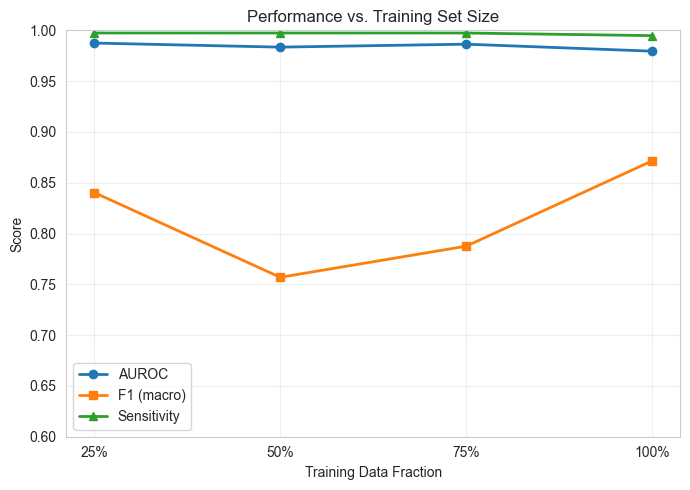

In [6]:
size_df = pd.DataFrame([
    {"Train Fraction": f"{frac*100:.0f}%", "AUROC": r["auroc"],
     "F1 (macro)": r["f1_macro"], "Sensitivity": r["sensitivity"],
     "Specificity": r["specificity"]}
    for frac, r in size_results.items()
])
print(size_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
x = [f"{f*100:.0f}%" for f in fractions]
ax.plot(x, [size_results[f]["auroc"] for f in fractions], "o-", label="AUROC", linewidth=2)
ax.plot(x, [size_results[f]["f1_macro"] for f in fractions], "s-", label="F1 (macro)", linewidth=2)
ax.plot(x, [size_results[f]["sensitivity"] for f in fractions], "^-", label="Sensitivity", linewidth=2)
ax.set_xlabel("Training Data Fraction")
ax.set_ylabel("Score")
ax.set_title("Performance vs. Training Set Size")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.6, 1.0)
plt.tight_layout()
plt.savefig("../results/ablation_data_size.png", bbox_inches="tight")
plt.show()

## Ablation 3: Model Components

- **Channel Attention**: SE-style block that re-weights feature channels.
- **Focal Loss**: Down-weights easy examples (gamma=2.0, alpha=0.6).

In [7]:
component_configs = {
    "Full model (attention + focal)": {"use_attention": True, "use_focal": True},
    "No attention": {"use_attention": False, "use_focal": True},
    "No focal loss": {"use_attention": True, "use_focal": False},
    "No attention, no focal": {"use_attention": False, "use_focal": False},
}

component_results = {}

for name, comp_cfg in component_configs.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    data_kwargs = {
        "augmentation": "standard",
        "image_size": config["data"]["image_size"],
        "batch_size": config["training"]["batch_size"],
        "val_split": config["data"]["val_split"],
    }
    model_kwargs = {
        "pretrained": True,
        "dropout": config["model"]["dropout"],
        "use_attention": comp_cfg["use_attention"],
    }

    run_config = copy.deepcopy(config)
    run_config["model"]["use_focal_loss"] = comp_cfg["use_focal"]

    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
    metrics = run_ablation_with_wandb(
        model_kwargs, data_kwargs, run_config,
        experiment_name=f"ablation_comp_{safe_name}",
        seed=SEED,
        wandb_tags=["ablation", "component"],
        wandb_group="component_ablation",
    )
    component_results[name] = metrics


Training: Full model (attention + focal)


Epoch   1/15 | Train Loss: 0.0220 | Val Loss: 0.0086 | Val AUROC: 0.9966 | F1: 0.9768 *
Epoch   2/15 | Train Loss: 0.0111 | Val Loss: 0.0091 | Val AUROC: 0.9965 | F1: 0.9699 
Epoch   3/15 | Train Loss: 0.0096 | Val Loss: 0.0082 | Val AUROC: 0.9984 | F1: 0.9786 *
Epoch   4/15 | Train Loss: 0.0089 | Val Loss: 0.0057 | Val AUROC: 0.9980 | F1: 0.9816 
Epoch   5/15 | Train Loss: 0.0071 | Val Loss: 0.0059 | Val AUROC: 0.9984 | F1: 0.9849 *
Epoch   6/15 | Train Loss: 0.0058 | Val Loss: 0.0060 | Val AUROC: 0.9985 | F1: 0.9851 *
Epoch   7/15 | Train Loss: 0.0053 | Val Loss: 0.0055 | Val AUROC: 0.9985 | F1: 0.9818 
Epoch   8/15 | Train Loss: 0.0036 | Val Loss: 0.0060 | Val AUROC: 0.9981 | F1: 0.9867 
Epoch   9/15 | Train Loss: 0.0034 | Val Loss: 0.0059 | Val AUROC: 0.9988 | F1: 0.9851 *
Epoch  10/15 | Train Loss: 0.0028 | Val Loss: 0.0057 | Val AUROC: 0.9988 | F1: 0.9884 
Epoch  11/15 | Train Loss: 0.0022 | Val Loss: 0.0082 | Val AUROC: 0.9989 | F1: 0.9818 *
Epoch  12/15 | Train Loss: 0.0017 | V

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▄▄▄▃▃▂▂▂▂▁▁▁▁▁
val/auroc,▁▁▆▅▆▆▆▅▇▇▇████
val/f1_macro,▄▁▄▅▇▇▅▇▇█▆▇▆▆▅
val/loss,▇█▆▁▂▂▁▂▂▁▆▂▇▃▄
val/sensitivity,▃▃▁▆█▄▄▆▅▆▃▅▃▄▃


  AUROC: 0.9903, F1: 0.8832

Training: No attention


Epoch   1/15 | Train Loss: 0.0217 | Val Loss: 0.0088 | Val AUROC: 0.9968 | F1: 0.9752 *
Epoch   2/15 | Train Loss: 0.0131 | Val Loss: 0.0087 | Val AUROC: 0.9986 | F1: 0.9850 *
Epoch   3/15 | Train Loss: 0.0088 | Val Loss: 0.0068 | Val AUROC: 0.9979 | F1: 0.9752 
Epoch   4/15 | Train Loss: 0.0083 | Val Loss: 0.0090 | Val AUROC: 0.9983 | F1: 0.9722 
Epoch   5/15 | Train Loss: 0.0070 | Val Loss: 0.0073 | Val AUROC: 0.9976 | F1: 0.9818 
Epoch   6/15 | Train Loss: 0.0062 | Val Loss: 0.0077 | Val AUROC: 0.9975 | F1: 0.9797 
Epoch   7/15 | Train Loss: 0.0052 | Val Loss: 0.0095 | Val AUROC: 0.9978 | F1: 0.9770 
Early stopping at epoch 7


...

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▄▄▃▃▃▂▂▂▂▁▁▁▁▁
val/auroc,▂▄▄▁▅█▆▇████▇█▇
val/f1_macro,▄▁▅▃▇▄▃█▃▇▇▇▅▇▆
val/loss,█▆▃▇▄▃▅▁▆▂▁▂▄▂▂
val/sensitivity,▆▁▅▂█▃▂█▂▇▇█▅▇▆


  AUROC: 0.9924, F1: 0.8990

Training: No attention, no focal


Epoch   1/15 | Train Loss: 0.1000 | Val Loss: 0.0710 | Val AUROC: 0.9981 | F1: 0.9054 *
Epoch   2/15 | Train Loss: 0.0533 | Val Loss: 0.0346 | Val AUROC: 0.9980 | F1: 0.9644 
Epoch   3/15 | Train Loss: 0.0369 | Val Loss: 0.0376 | Val AUROC: 0.9974 | F1: 0.9628 
Epoch   4/15 | Train Loss: 0.0363 | Val Loss: 0.0372 | Val AUROC: 0.9973 | F1: 0.9644 
Epoch   5/15 | Train Loss: 0.0341 | Val Loss: 0.0413 | Val AUROC: 0.9961 | F1: 0.9866 
Epoch   6/15 | Train Loss: 0.0271 | Val Loss: 0.0629 | Val AUROC: 0.9947 | F1: 0.9521 
Early stopping at epoch 6


epoch,▁▂▄▅▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▄▂▂▂▁
val/auroc,██▇▆▄▁
val/f1_macro,▁▆▆▆█▅
val/loss,█▁▂▁▂▆
val/sensitivity,▁▆▆▆█▅


  AUROC: 0.9815, F1: 0.9272


                 Configuration    AUROC  F1 (macro)  Sensitivity  Specificity
Full model (attention + focal) 0.990346    0.883178     0.997436     0.730769
                  No attention 0.981975    0.792165     0.997436     0.547009
                 No focal loss 0.992395    0.899038     0.994872     0.769231
        No attention, no focal 0.981471    0.927158     0.966667     0.876068


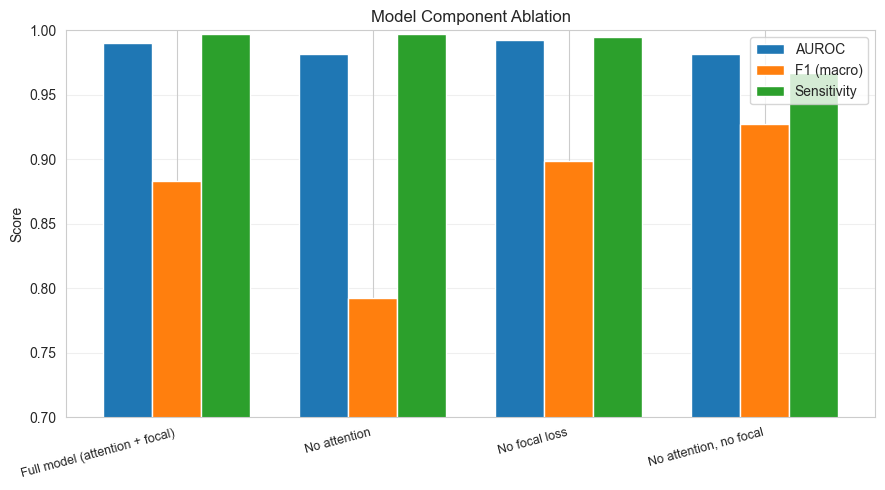

In [8]:
comp_df = pd.DataFrame([
    {"Configuration": name, "AUROC": r["auroc"], "F1 (macro)": r["f1_macro"],
     "Sensitivity": r["sensitivity"], "Specificity": r["specificity"]}
    for name, r in component_results.items()
])
print(comp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(component_results))
width = 0.25
names = list(component_results.keys())
ax.bar(x - width, [component_results[n]["auroc"] for n in names], width, label="AUROC")
ax.bar(x, [component_results[n]["f1_macro"] for n in names], width, label="F1 (macro)")
ax.bar(x + width, [component_results[n]["sensitivity"] for n in names], width, label="Sensitivity")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Model Component Ablation")
ax.legend()
ax.set_ylim(0.7, 1.0)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../results/ablation_components.png", bbox_inches="tight")
plt.show()

## Multiple Runs with Different Seeds

In [9]:
multi_run_results = []

for i, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"Run {i+1}/{len(SEEDS)} with seed={seed}")
    print(f"{'='*60}")

    data_kwargs = {
        "augmentation": "standard",
        "image_size": config["data"]["image_size"],
        "batch_size": config["training"]["batch_size"],
        "val_split": config["data"]["val_split"],
    }
    model_kwargs = {
        "pretrained": True,
        "dropout": config["model"]["dropout"],
        "use_attention": True,
    }

    metrics = run_ablation_with_wandb(
        model_kwargs, data_kwargs, config,
        experiment_name=f"multirun_seed_{seed}",
        seed=seed,
        wandb_tags=["ablation", "multi_run"],
        wandb_group="multi_run_seeds",
    )
    multi_run_results.append({"seed": seed, **metrics})


Run 1/5 with seed=42


Epoch   1/15 | Train Loss: 0.0215 | Val Loss: 0.0106 | Val AUROC: 0.9962 | F1: 0.9610 *
Epoch   2/15 | Train Loss: 0.0128 | Val Loss: 0.0085 | Val AUROC: 0.9968 | F1: 0.9781 *
Epoch   3/15 | Train Loss: 0.0089 | Val Loss: 0.0096 | Val AUROC: 0.9979 | F1: 0.9771 *
Epoch   4/15 | Train Loss: 0.0081 | Val Loss: 0.0068 | Val AUROC: 0.9973 | F1: 0.9767 
Epoch   5/15 | Train Loss: 0.0073 | Val Loss: 0.0078 | Val AUROC: 0.9976 | F1: 0.9814 
Epoch   6/15 | Train Loss: 0.0061 | Val Loss: 0.0075 | Val AUROC: 0.9982 | F1: 0.9819 *
Epoch   7/15 | Train Loss: 0.0061 | Val Loss: 0.0071 | Val AUROC: 0.9972 | F1: 0.9834 
Epoch   8/15 | Train Loss: 0.0048 | Val Loss: 0.0070 | Val AUROC: 0.9971 | F1: 0.9817 
Epoch   9/15 | Train Loss: 0.0038 | Val Loss: 0.0099 | Val AUROC: 0.9981 | F1: 0.9738 
Epoch  10/15 | Train Loss: 0.0029 | Val Loss: 0.0071 | Val AUROC: 0.9979 | F1: 0.9802 
Epoch  11/15 | Train Loss: 0.0024 | Val Loss: 0.0082 | Val AUROC: 0.9977 | F1: 0.9835 
Early stopping at epoch 11


epoch,▁▂▂▃▄▅▅▆▇▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▅▃▃▃▂▂▂▁▁▁
val/auroc,▁▃▇▅▆█▄▄█▇▆
val/f1_macro,▁▆▆▆▇▇█▇▅▇█
val/loss,█▄▆▁▃▂▂▁▇▂▄
val/sensitivity,▅▇▂▄█▄▅▅▁▄▄


  AUROC: 0.9825, F1: 0.8815

Run 2/5 with seed=123


Epoch   1/15 | Train Loss: 0.0213 | Val Loss: 0.0079 | Val AUROC: 0.9973 | F1: 0.9697 *
Epoch   2/15 | Train Loss: 0.0116 | Val Loss: 0.0122 | Val AUROC: 0.9987 | F1: 0.9676 *
Epoch   3/15 | Train Loss: 0.0104 | Val Loss: 0.0042 | Val AUROC: 0.9997 | F1: 0.9832 *
Epoch   4/15 | Train Loss: 0.0082 | Val Loss: 0.0040 | Val AUROC: 0.9995 | F1: 0.9834 
Epoch   5/15 | Train Loss: 0.0066 | Val Loss: 0.0030 | Val AUROC: 0.9998 | F1: 0.9917 *
Epoch   6/15 | Train Loss: 0.0070 | Val Loss: 0.0028 | Val AUROC: 0.9998 | F1: 0.9917 
Epoch   7/15 | Train Loss: 0.0048 | Val Loss: 0.0038 | Val AUROC: 0.9995 | F1: 0.9834 
Epoch   8/15 | Train Loss: 0.0051 | Val Loss: 0.0039 | Val AUROC: 0.9998 | F1: 0.9868 
Epoch   9/15 | Train Loss: 0.0039 | Val Loss: 0.0032 | Val AUROC: 0.9998 | F1: 0.9884 
Epoch  10/15 | Train Loss: 0.0023 | Val Loss: 0.0035 | Val AUROC: 0.9998 | F1: 0.9884 
Early stopping at epoch 10


...

epoch,▁▂▃▃▄▅▆▆▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▅▃▃▂▂▂▁▁▁
val/auroc,▁▂▄▇█▆▆▆▇▇
val/f1_macro,▅▁▄▆▆▇█▇▆█
val/loss,██▆▁▂▁▁▂▄▃
val/sensitivity,█▁▄▅▅▇▇▅▅▆


  AUROC: 0.9820, F1: 0.9073

Run 5/5 with seed=1024


Epoch   1/15 | Train Loss: 0.0224 | Val Loss: 0.0087 | Val AUROC: 0.9994 | F1: 0.9779 *
Epoch   2/15 | Train Loss: 0.0127 | Val Loss: 0.0059 | Val AUROC: 0.9991 | F1: 0.9744 
Epoch   3/15 | Train Loss: 0.0102 | Val Loss: 0.0064 | Val AUROC: 0.9993 | F1: 0.9770 
Epoch   4/15 | Train Loss: 0.0088 | Val Loss: 0.0033 | Val AUROC: 0.9995 | F1: 0.9883 *
Epoch   5/15 | Train Loss: 0.0067 | Val Loss: 0.0054 | Val AUROC: 0.9993 | F1: 0.9786 
Epoch   6/15 | Train Loss: 0.0057 | Val Loss: 0.0066 | Val AUROC: 0.9994 | F1: 0.9745 
Epoch   7/15 | Train Loss: 0.0067 | Val Loss: 0.0042 | Val AUROC: 0.9996 | F1: 0.9867 *
Epoch   8/15 | Train Loss: 0.0036 | Val Loss: 0.0040 | Val AUROC: 0.9996 | F1: 0.9868 
Epoch   9/15 | Train Loss: 0.0038 | Val Loss: 0.0031 | Val AUROC: 0.9998 | F1: 0.9934 *
Epoch  10/15 | Train Loss: 0.0031 | Val Loss: 0.0032 | Val AUROC: 0.9996 | F1: 0.9867 
Epoch  11/15 | Train Loss: 0.0028 | Val Loss: 0.0036 | Val AUROC: 0.9997 | F1: 0.9851 
Epoch  12/15 | Train Loss: 0.0021 | Val

epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▅▄▃▃▂▃▂▂▂▁▁▁▁
val/auroc,▄▁▃▆▃▄▆▆█▇█▇▇▇
val/f1_macro,▂▁▂▆▃▁▆▆█▆▅▇▇▇
val/loss,█▅▅▁▄▅▂▂▁▁▂▁▁▁
val/sensitivity,██▁▆▂▇▅▅▆▆▄▆▆▆


  AUROC: 0.9865, F1: 0.8775


In [10]:
mr_df = pd.DataFrame(multi_run_results)

print("Per-run results:")
print(mr_df[["seed", "auroc", "f1_macro", "sensitivity", "specificity"]].to_string(index=False))

print("\nAggregated statistics:")
for col in ["auroc", "f1_macro", "sensitivity", "specificity", "npv"]:
    mean = mr_df[col].mean()
    std = mr_df[col].std()
    print(f"  {col:>15s}: {mean:.4f} +/- {std:.4f}")

Per-run results:
 seed    auroc  f1_macro  sensitivity  specificity
   42 0.982544  0.881503     0.994872     0.730769
  123 0.982205  0.845004     0.994872     0.653846
  456 0.987245  0.823271     0.997436     0.606838
  789 0.981996  0.907337     0.987179     0.799145
 1024 0.986544  0.877545     0.994872     0.722222

Aggregated statistics:
            auroc: 0.9841 +/- 0.0026
         f1_macro: 0.8669 +/- 0.0330
      sensitivity: 0.9938 +/- 0.0039
      specificity: 0.7026 +/- 0.0742
              npv: 0.9862 +/- 0.0072


multi_run_auroc_mean,0.98411
multi_run_auroc_std,0.00256
multi_run_f1_macro_mean,0.86693
multi_run_f1_macro_std,0.03296
multi_run_npv_mean,0.98616
multi_run_npv_std,0.00718
multi_run_sensitivity_mean,0.99385
multi_run_sensitivity_std,0.00389
multi_run_specificity_mean,0.70256
multi_run_specificity_std,0.07424


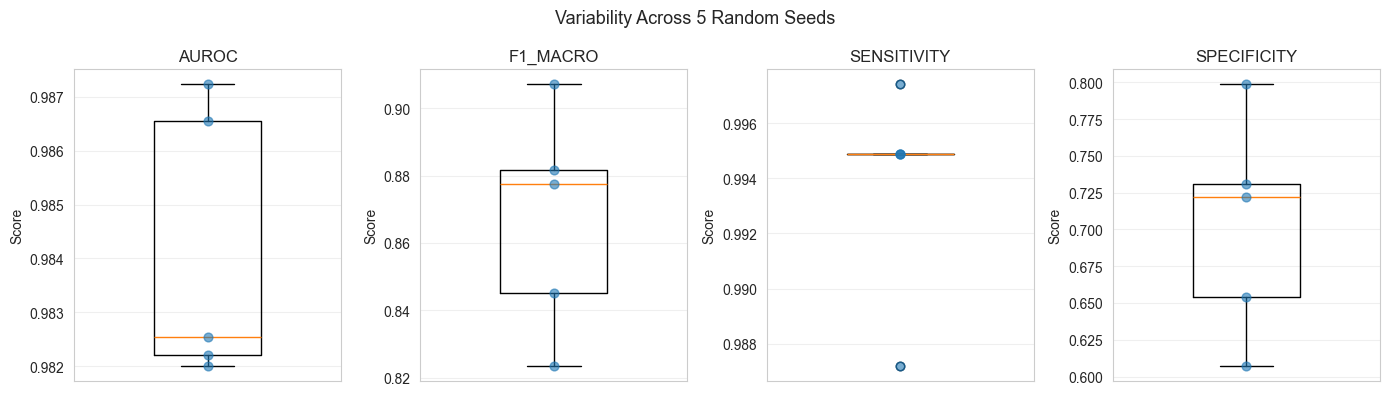

In [11]:
# Log multi-run summary
if USE_WANDB:
    run = wandb_init(name="multi_run_summary", job_type="analysis",
                     tags=["summary", "multi_run"], reinit=True)
    wandb_log_table(
        "multi_run/results_table",
        columns=["seed", "auroc", "f1_macro", "sensitivity", "specificity", "npv"],
        data=[
            [r["seed"], r["auroc"], r["f1_macro"], r["sensitivity"], r["specificity"], r["npv"]]
            for r in multi_run_results
        ],
        run=run,
    )
    for col in ["auroc", "f1_macro", "sensitivity", "specificity", "npv"]:
        wandb_summary({f"multi_run_{col}_mean": float(mr_df[col].mean()),
                       f"multi_run_{col}_std": float(mr_df[col].std())}, run)

metrics_to_plot = ["auroc", "f1_macro", "sensitivity", "specificity"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))
for i, metric in enumerate(metrics_to_plot):
    values = mr_df[metric].values
    axes[i].boxplot(values, widths=0.4)
    axes[i].scatter(np.ones(len(values)), values, alpha=0.6, s=40, zorder=3)
    axes[i].set_title(metric.upper())
    axes[i].set_ylabel("Score")
    axes[i].set_xticks([])
    axes[i].grid(True, alpha=0.3, axis="y")
plt.suptitle("Variability Across 5 Random Seeds", fontsize=13)
plt.tight_layout()

if USE_WANDB:
    wandb_log_image("multi_run/variability_boxplot", fig, run)
    wandb_finish(run)

plt.savefig("../results/ablation_multirun.png", bbox_inches="tight")
plt.show()

## Save all ablation results

In [12]:
all_ablation_results = {
    "augmentation_ablation": {k: v for k, v in aug_results.items()},
    "data_size_ablation": {str(k): v for k, v in size_results.items()},
    "component_ablation": component_results,
    "multi_run": multi_run_results,
    "multi_run_summary": {
        col: {"mean": float(mr_df[col].mean()), "std": float(mr_df[col].std())}
        for col in ["auroc", "f1_macro", "sensitivity", "specificity", "npv"]
    },
}

save_results(all_ablation_results, "ablation_results", output_dir="../results")
print("All ablation results saved.")

All ablation results saved.


In [13]:
import gc
gc.collect()
torch.cuda.empty_cache()